In [1]:
import glob
import ast
import time
import numpy as np
import pandas as pd
from tqdm import tqdm 
import cv2
from PIL import Image
import re
import joblib
import matplotlib.pyplot as plt
import gc
import zipfile

from tqdm import tqdm
import shutil

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Loading package

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir,verifyFile

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

DATA_PATH = os.getenv('DATA_PATH')
MODEL_PATH = os.getenv('MODEL_PATH')
DATA_PATH, MODEL_PATH

('/media/felipe/DATA19/datasets/', '/media/felipe/DATA19/models/')

In [6]:
MODEL_NAME="OneFormer_Swin_Large"
SEG_DATASET="ade20k" # cityscapes

In [7]:
ADE20K_DIR = f"{DATA_PATH}{SEG_DATASET}/"
UPD4K_DIR = f"{DATA_PATH}/upd4k/"

QSCORE_PATH=f"{DATA_PATH}pp2/Qscores/"
IMAGES_PATH = f"{DATA_PATH}pp2/images/"
SEGMENT_DIR = f"{DATA_PATH}pp2/segmentations/{SEG_DATASET}/{MODEL_NAME}/"
UPD_SEGMENT_DIR = f"{DATA_PATH}UrbanPhysicalDisorder/upd4k/"

In [8]:
verifyDir(UPD_SEGMENT_DIR)

### Loading data

In [9]:
from py.datasets import UrbanPhysicalDisorder

uss = UrbanPhysicalDisorder(data_path=DATA_PATH)
uss.generate_dataset(dataset="ade20k_upd4k")

objects_df = uss.get_urban_street_categories()
objects_df

,class_id,main_class,class_name,RGB_color,hex_color,isthing,group_name
0,1,wall,wall,"(120, 120, 120)",#787878,0,construction
1,2,building,building;edifice,"(180, 120, 120)",#B47878,0,construction
2,3,sky,sky,"(6, 230, 230)",#06E6E6,0,sky
3,4,floor,floor;flooring,"(80, 50, 50)",#503232,0,floor
4,5,tree,tree,"(4, 200, 3)",#04C803,0,vegetation
...,...,...,...,...,...,...,...
158,159,graffiti,graffiti,"(170, 240, 209)",#aaf0d1,0,graffiti
159,160,homeless,homeless,"(255, 204, 51)",#ffcc33,1,homeless
160,161,kiosk,kiosk,"(204, 51, 102)",#cc3366,1,kiosk
161,162,overhead_cable,overhead_cable,"(250, 125, 187)",#fa7dbb,0,overhead_cable


### Merging masks

In [10]:
import fnmatch

In [11]:
columns_to_keep = ["image_id", "seg_image_path", "seg_overlay_image_path", "mask_path", "ratio_path"]

In [12]:
%%time
for current_city in ["Rio De Janeiro"]:
    OUT_DIR = f"{UPD_SEGMENT_DIR}{current_city}/"
    
    verifyDir(OUT_DIR)
    verifyDir(f"{OUT_DIR}/masks/")
    verifyDir(f"{OUT_DIR}/segmented_images/")
    verifyDir(f"{OUT_DIR}/segmented_images_overlay/")
    verifyDir(f"{OUT_DIR}/ratios/")
    
    merge_segment_df = pd.DataFrame()
    manual_segment_df = pd.DataFrame()
    # model_segment_df = pd.DataFrame()
    
    usd_c_dir = f'{UPD4K_DIR}/{current_city}/'
    
    #manual_img_seg_list = np.sort([f for f in glob.glob(f'{usd_c_dir}/SegmentationClass/*.png')])
    with zipfile.ZipFile(f'{UPD4K_DIR}/{current_city}.zip', 'r') as zip_ref:
        # Get all PNG files in SegmentationClass directory
        manual_img_seg_list = np.sort([f'{UPD4K_DIR}{f}' for f in zip_ref.namelist() 
                     if fnmatch.fnmatch(f, f'{current_city}/SegmentationClass/*.png')])
    
    manual_img_seg_ids = [ img.split("/")[-1].replace(".png", "") for img in manual_img_seg_list]
    
    img_seg_list = np.sort([f for f in glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images/*.png') ])
    img_seg_ids = [ img.split("/")[-1].replace(".png", "") for img in img_seg_list]
    
    for img_path in tqdm(img_seg_list):
        
        current_id = img_path.split("/")[-1].replace(".JPEG", "").replace(".png", "")
    
        current_image = Image.open(glob.glob(f'{IMAGES_PATH}/{current_city}/{current_id}.JPG')[0]).convert("RGB")
        
        if current_id in manual_img_seg_ids:
            manual_img_seg = Image.open(
                                zipfile.ZipFile(f'{UPD4K_DIR}/{current_city}.zip')
                                .open(f'{current_city}/SegmentationClass/{current_id}.png')
                            ).convert("RGB")
            
            colors_tuple = uss.calculate_unique_colors(manual_img_seg, to_tuple=True)
    
            # Calculate manual masks ratios
            manual_masks = uss.convert_mask_to_matrix(manual_img_seg, colors_tuple, objects_df)
            manual_df = uss.calculate_pixel_ratios(manual_masks, objects_df)
            manual_pivot_df = uss.parse_ratios(current_id, manual_df)
            manual_pivot_df["seg_image_path"] = f"{current_city}/segmented_images/{current_id}.png"
            manual_pivot_df["seg_overlay_image_path"] = f"{current_city}/segmented_images_overlay/{current_id}.png"
            manual_pivot_df["mask_path"] = f"{current_city}/masks/{current_id}.pkl"
            manual_pivot_df["ratio_path"] = f"{current_city}/ratios/{current_id}.csv"
            
            manual_segment_df = pd.concat([manual_segment_df, manual_pivot_df], ignore_index=True)
            manual_segment_df = manual_segment_df[columns_to_keep + [col for col in manual_segment_df.columns if col not in columns_to_keep]].copy()
            manual_segment_df.fillna(0, inplace=True)
    
            # Calculate real masks ratios
            model_masks = joblib.load(glob.glob(f'{SEGMENT_DIR}/{current_city}/masks/{current_id}.pkl')[0])
            
            # merging masks
            merged_masks = np.where(manual_masks != 0, manual_masks, model_masks)
            joblib.dump(merged_masks, f"{UPD_SEGMENT_DIR}{current_city}/masks/{current_id}.pkl")
            ratio_df = uss.calculate_pixel_ratios(merged_masks, objects_df)
            ratio_df.to_csv(f"{UPD_SEGMENT_DIR}{current_city}/ratios/{current_id}.csv", sep=";", index=False)
    
            # merging both images
            ade20k_img_seg = Image.open(glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images/{current_id}.png')[0]).convert("RGB")
            merged_img_seg = uss.merge_segmentations(ade20k_img_seg, manual_img_seg)
            merged_image = Image.fromarray(merged_img_seg)
            merged_image.save(f"{UPD_SEGMENT_DIR}{current_city}/segmented_images/{current_id}.png")
    
            # Overlay image
            image_overlay = Image.blend(current_image, merged_image, alpha=0.6)
            image_overlay.save(f"{UPD_SEGMENT_DIR}{current_city}/segmented_images_overlay/{current_id}.png")
    
        else:
            # copying masks
            model_masks = joblib.load(glob.glob(f'{SEGMENT_DIR}/{current_city}/masks/{current_id}.pkl')[0])
            source = glob.glob(f'{SEGMENT_DIR}/{current_city}/masks/{current_id}.pkl')[0]
            destination = f"{UPD_SEGMENT_DIR}{current_city}/masks/{current_id}.pkl"
            shutil.copy(source, destination)
    
            # copying ratios
            source = glob.glob(f'{SEGMENT_DIR}/{current_city}/ratios/{current_id}.csv')[0]
            destination = f"{UPD_SEGMENT_DIR}{current_city}/ratios/{current_id}.csv"
            shutil.copy(source, destination)
    
            # copying image segmentation
            source = glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images/{current_id}.png')[0]
            destination = f"{UPD_SEGMENT_DIR}{current_city}/segmented_images/{current_id}.png"
            shutil.copy(source, destination)
    
            # copying image overlay
            source = glob.glob(f'{SEGMENT_DIR}/{current_city}/segmented_images_overlay/{current_id}.png')[0]
            destination = f"{UPD_SEGMENT_DIR}{current_city}/segmented_images_overlay/{current_id}.png"
            shutil.copy(source, destination)
    
            # read ratios to append
            ratio_df = pd.read_csv(f'{SEGMENT_DIR}/{current_city}/ratios/{current_id}.csv', sep=";", low_memory=False)
    
        # model segmentations
        # model_df = uss.calculate_pixel_ratios(model_masks, objects_df)
        # model_pivot_df = uss.parse_ratios(current_id, model_df)
        # model_segment_df = pd.concat([model_segment_df, model_pivot_df], ignore_index=True)
        # model_segment_df = model_segment_df[columns_to_keep + [col for col in model_segment_df.columns if col not in columns_to_keep]].copy()
        # model_segment_df.fillna(0, inplace=True)
    
        # merge segmentations
        merge_pivot_df = uss.parse_ratios(current_id, ratio_df)
        merge_pivot_df["seg_image_path"] = f"{current_city}/segmented_images/{current_id}.png"
        merge_pivot_df["seg_overlay_image_path"] = f"{current_city}/segmented_images_overlay/{current_id}.png"
        merge_pivot_df["mask_path"] = f"{current_city}/masks/{current_id}.pkl"
        merge_pivot_df["ratio_path"] = f"{current_city}/ratios/{current_id}.csv"
        
        merge_segment_df = pd.concat([merge_segment_df, merge_pivot_df], ignore_index=True)
        merge_segment_df = merge_segment_df[columns_to_keep + [col for col in merge_segment_df.columns if col not in columns_to_keep]].copy()
        merge_segment_df.fillna(0, inplace=True)
    
    manual_segment_df.to_csv(f"{UPD_SEGMENT_DIR}{current_city}/upd4k_segmentations.csv", sep=";", index=False)
    merge_segment_df.to_csv(f"{UPD_SEGMENT_DIR}{current_city}/segmentations.csv", sep=";", index=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3644/3644 [42:59<00:00,  1.41it/s]

CPU times: user 8min 3s, sys: 12.6 s, total: 8min 16s
Wall time: 42min 59s


### Summary

In [13]:
manual_segment_df = pd.read_csv(f"{UPD_SEGMENT_DIR}{current_city}/upd4k_segmentations.csv", sep=";", low_memory=False)
merge_segment_df = pd.read_csv(f"{UPD_SEGMENT_DIR}{current_city}/segmentations.csv", sep=";", low_memory=False)

In [14]:
manual_segment_df.shape, merge_segment_df.shape#, model_segment_df.shape

((3253, 18), (3644, 113))

In [15]:
set(merge_segment_df.columns) - set(manual_segment_df.columns)#, set(merge_segment_df.columns) - set(model_segment_df.columns)

{'airplane',
 'animal',
 'armchair',
 'ashcan',
 'awning',
 'bag',
 'ball',
 'basket',
 'bench',
 'bicycle',
 'billiard',
 'boat',
 'bottle',
 'box',
 'bridge',
 'building',
 'bulletin',
 'bus',
 'car',
 'carpet',
 'ceiling',
 'chair',
 'clock',
 'column',
 'conveyor',
 'curtain',
 'door',
 'fan',
 'fence',
 'field',
 'flag',
 'floor',
 'flower',
 'flowerpot',
 'fountain',
 'grandstand',
 'grass',
 'ground',
 'handrail',
 'hill',
 'house',
 'lake',
 'lamp',
 'land',
 'light',
 'mirror',
 'motorcycle',
 'mountain',
 'palm',
 'path',
 'pedestal',
 'person',
 'pier',
 'plant',
 'plaything',
 'pole',
 'poster',
 'railing',
 'river',
 'road',
 'rock',
 'sand',
 'sculpture',
 'sea',
 'shack',
 'shelf',
 'ship',
 'sidewalk',
 'signboard',
 'sink',
 'sky',
 'skyscraper',
 'sofa',
 'sofa_pillow',
 'stadium',
 'stairs',
 'stairway',
 'stand',
 'steps',
 'stoplight',
 'streetlight',
 'swimming_pool',
 'table',
 'tank',
 'television',
 'tent',
 'tower',
 'trade',
 'tree',
 'truck',
 'van',
 'vitri

In [16]:
metric="safety"

In [17]:
%%time
data_df = pd.read_csv(f"{QSCORE_PATH}scores.csv", sep=";", low_memory=False)
manual_segmentation_df = pd.merge(data_df, manual_segment_df, on="image_id", how="inner")
manual_segmentation_df.sort_values(by=metric, inplace=True, ascending=False)
manual_segmentation_df

CPU times: user 175 ms, sys: 16 ms, total: 191 ms
Wall time: 515 ms


,image_id,lat,long,city,country,continent,safety,beautiful,wealthy,lively,...,graffiti,trashcan,broken_damaged_bricks_wall,car_taxi,garbage_box,kiosk,homeless,damaged_traffic_sign,car_police,broken_window
815,50f5eaecfdc9f065f0007e32,-22.901318,-43.178843,Rio De Janeiro,Brasil,South America,8.074111,7.222222,6.521164,5.259259,...,0.000000,0.000000,0.000000,10.947500,0.0,0.0,0.000000,0.0,0.0,0.0
1679,50f5eb4bfdc9f065f00081e0,-22.924839,-43.387912,Rio De Janeiro,Brasil,South America,7.990805,3.015873,3.333333,3.767806,...,0.000000,0.000000,0.848333,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
1546,50f5eb44fdc9f065f0008149,-22.946271,-43.371826,Rio De Janeiro,Brasil,South America,7.845118,5.000000,3.333333,3.347885,...,0.000000,0.000000,0.000000,0.341667,0.0,0.0,0.000000,0.0,0.0,0.0
154,50f5eaa3fdc9f065f0007b62,-22.848260,-43.265251,Rio De Janeiro,Brasil,South America,7.784127,2.222222,3.333333,4.777778,...,3.378333,0.000000,1.232500,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
2181,50f5ebaafdc9f065f0008430,-22.911389,-43.194286,Rio De Janeiro,Brasil,South America,7.758611,5.836508,5.000000,5.695847,...,0.000000,0.250833,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2767,50f5ec14fdc9f065f00086db,-22.890452,-43.381059,Rio De Janeiro,Brasil,South America,0.909091,4.611111,4.662698,5.219841,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
480,50f5eac8fdc9f065f0007ccc,-22.775293,-43.391274,Rio De Janeiro,Brasil,South America,0.833333,2.500000,1.666667,5.274365,...,0.000000,0.000000,1.839167,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
2490,50f5ebcefdc9f065f0008595,-22.875385,-43.278050,Rio De Janeiro,Brasil,South America,0.833333,2.190476,2.500000,1.929293,...,0.000000,0.000000,9.931667,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
1364,50f5eb27fdc9f065f000807f,-22.853284,-43.319558,Rio De Janeiro,Brasil,South America,0.512821,3.333333,2.222222,4.174539,...,3.913333,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


### Object Presence

#### All samples

In [20]:
manual_segmentation_df.info()

<class 'pandas.DataFrame'>
Index: 3253 entries, 815 to 3247
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   image_id                      3253 non-null   str    
 1   lat                           3253 non-null   float64
 2   long                          3253 non-null   float64
 3   city                          3253 non-null   str    
 4   country                       3253 non-null   str    
 5   continent                     3253 non-null   str    
 6   safety                        3253 non-null   float64
 7   beautiful                     3253 non-null   float64
 8   wealthy                       3253 non-null   float64
 9   lively                        3253 non-null   float64
 10  boring                        3253 non-null   float64
 11  depressing                    3253 non-null   float64
 12  image_path                    3253 non-null   str    
 13  seg_image_path   

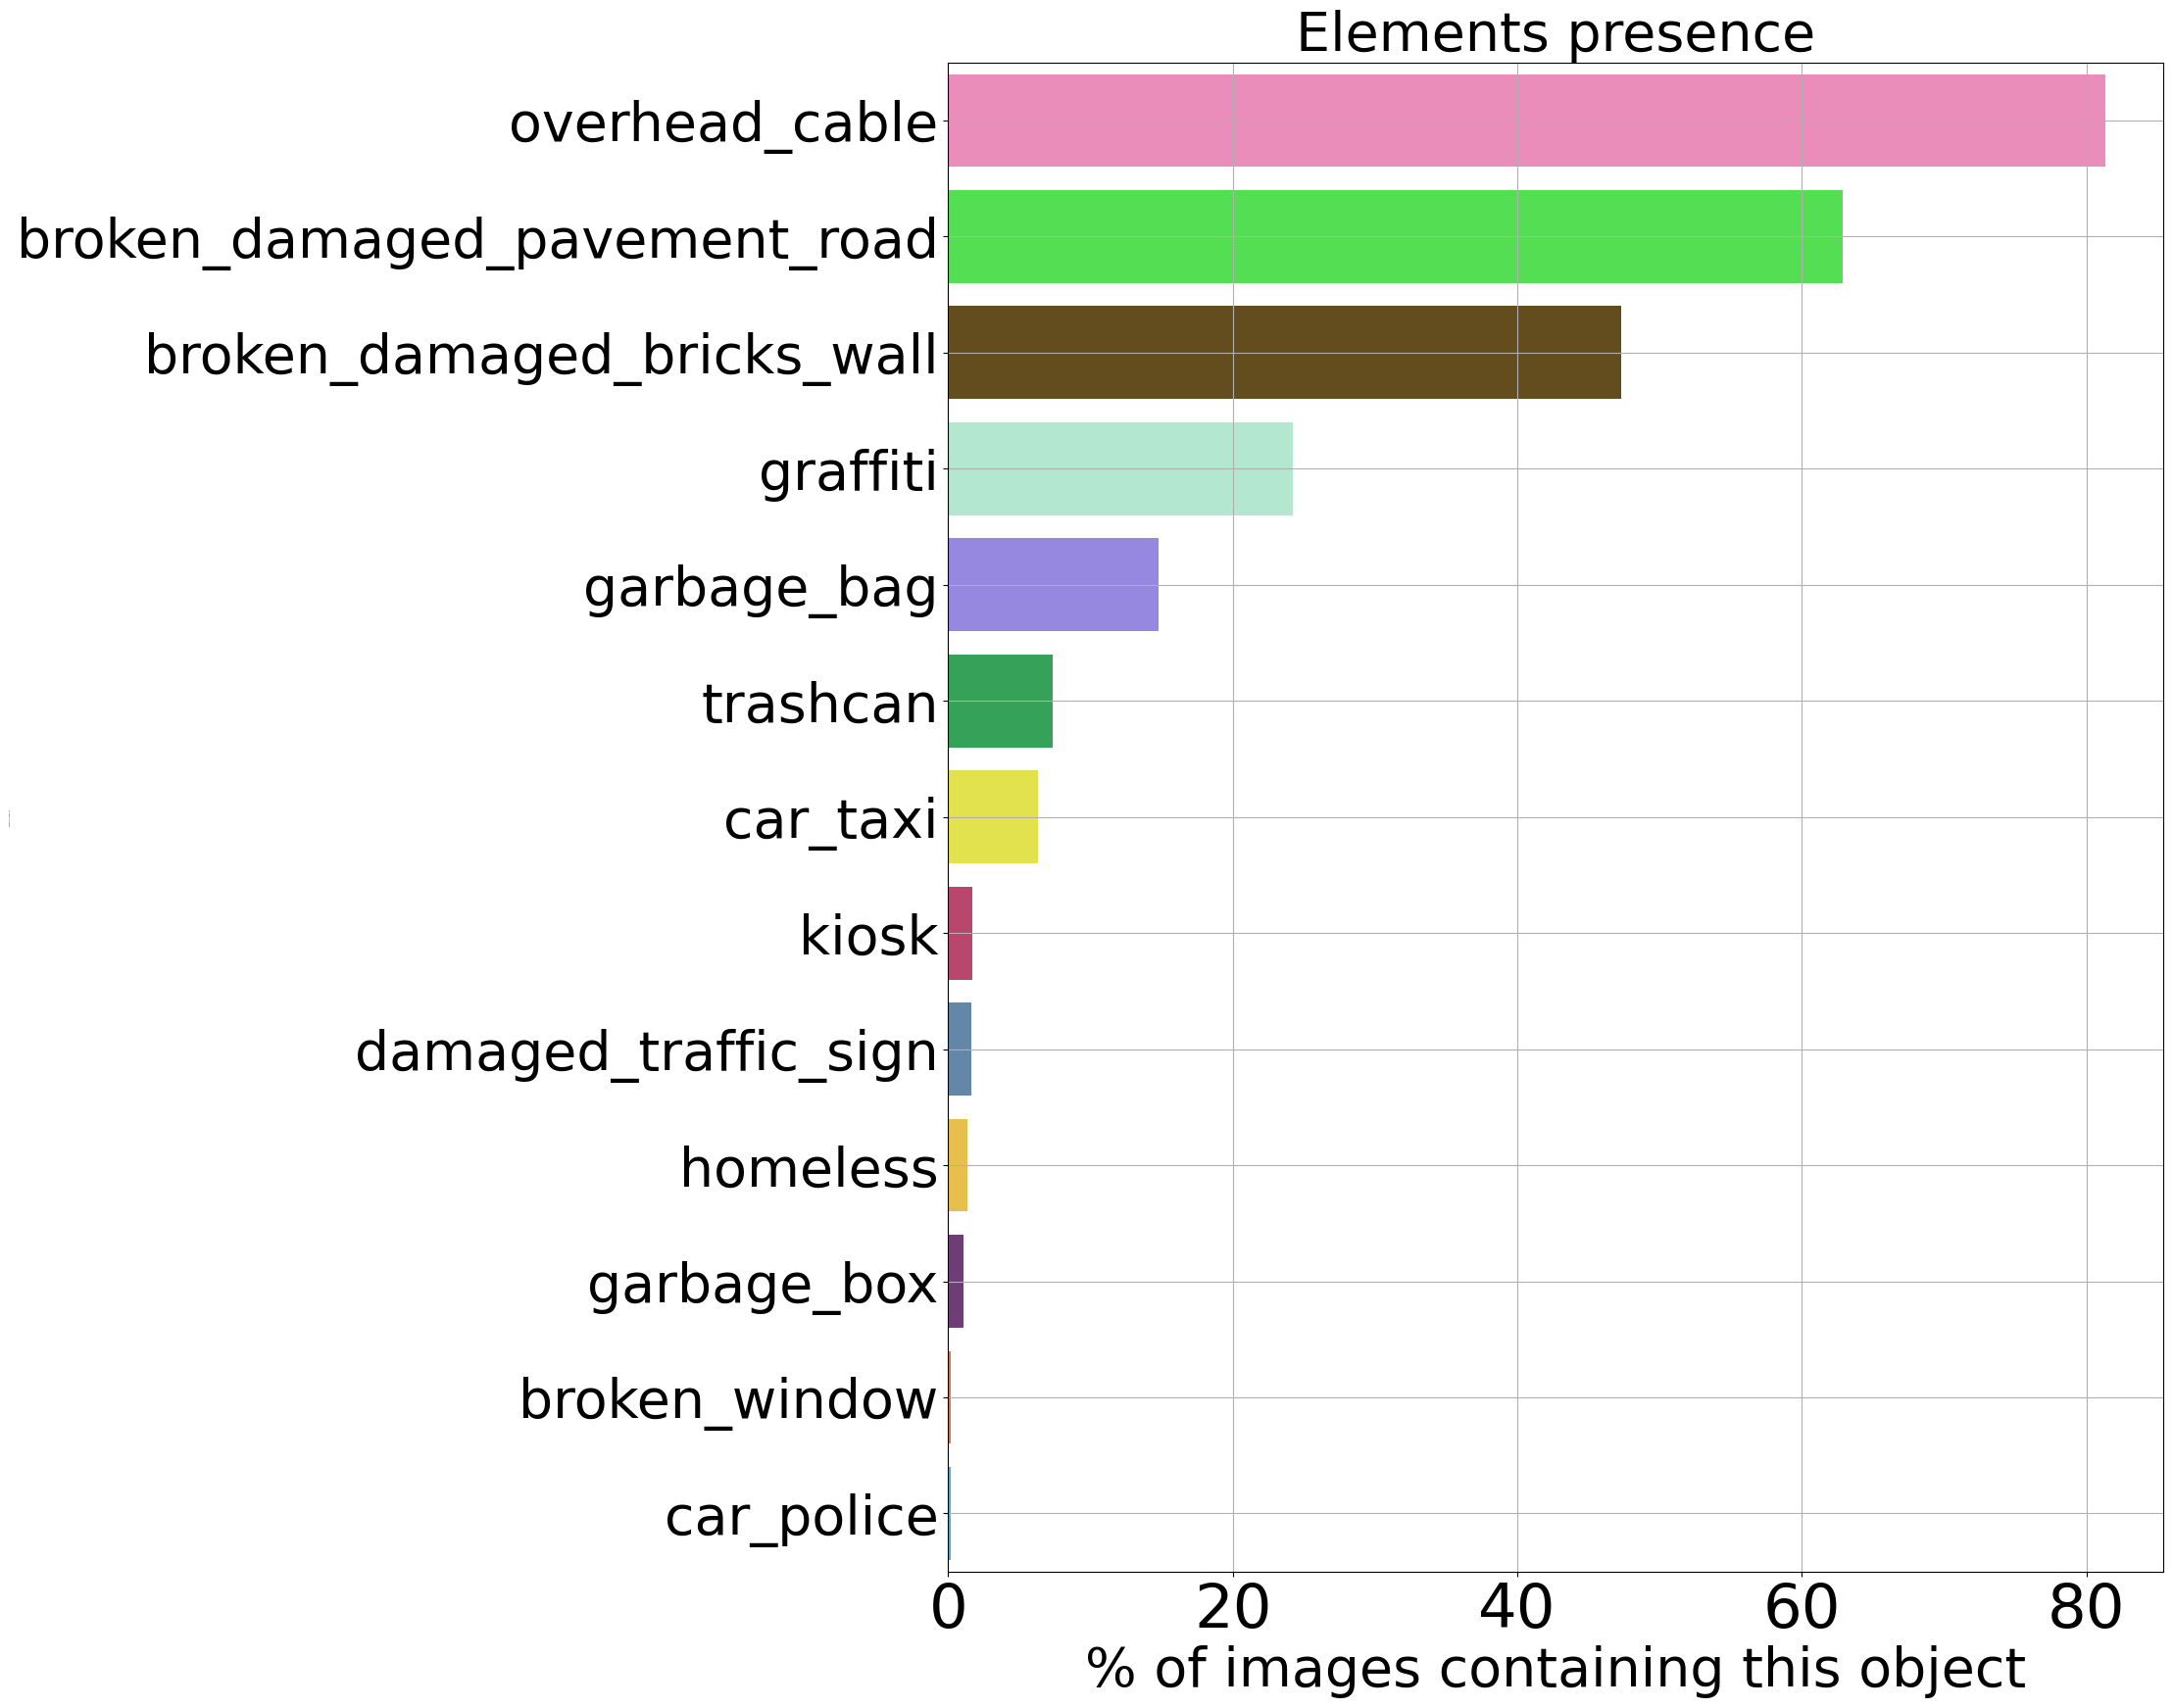

In [21]:
feature_presence = uss.features_presence(manual_segmentation_df.iloc[:, 17:])
feature_presence[0] = feature_presence[0]*100
uss.print_object_present(feature_presence, fig_size=(16,20))

#### Positive samples

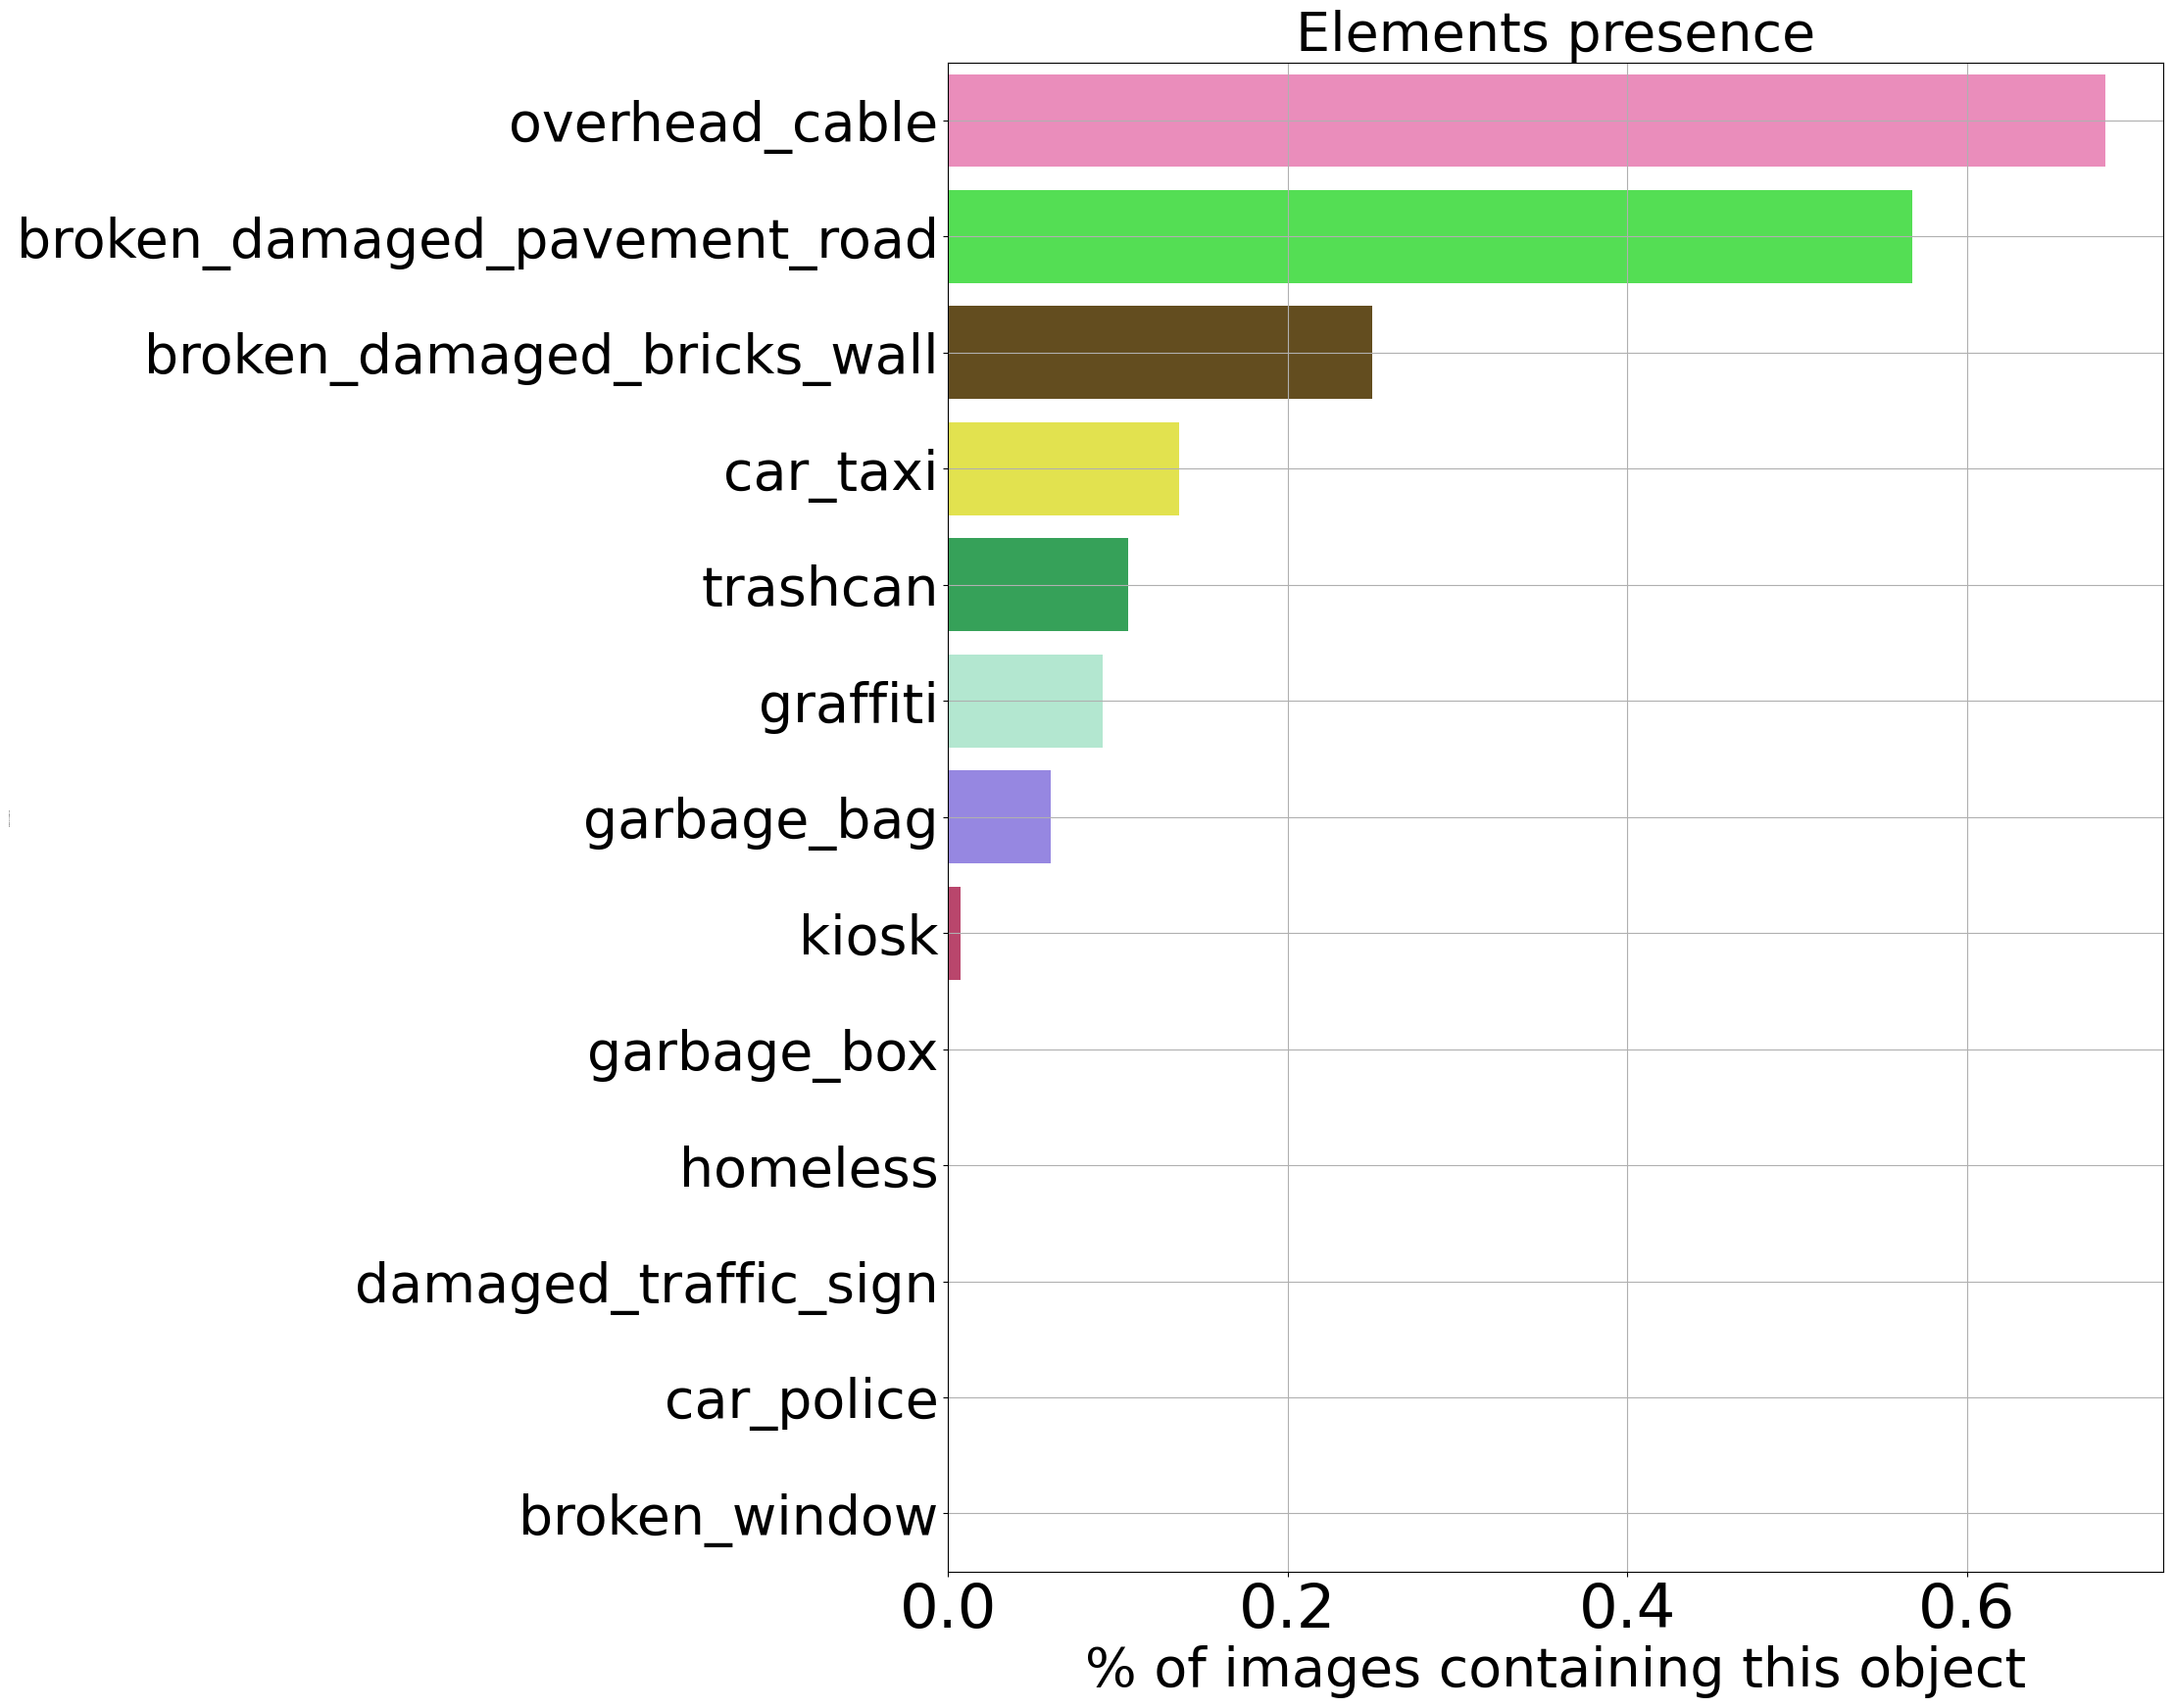

In [22]:
feature_presence = uss.features_presence(manual_segmentation_df[manual_segmentation_df[metric]>=6].iloc[:, 17:])
uss.print_object_present(feature_presence, fig_size=(16,20))

#### Negative samples

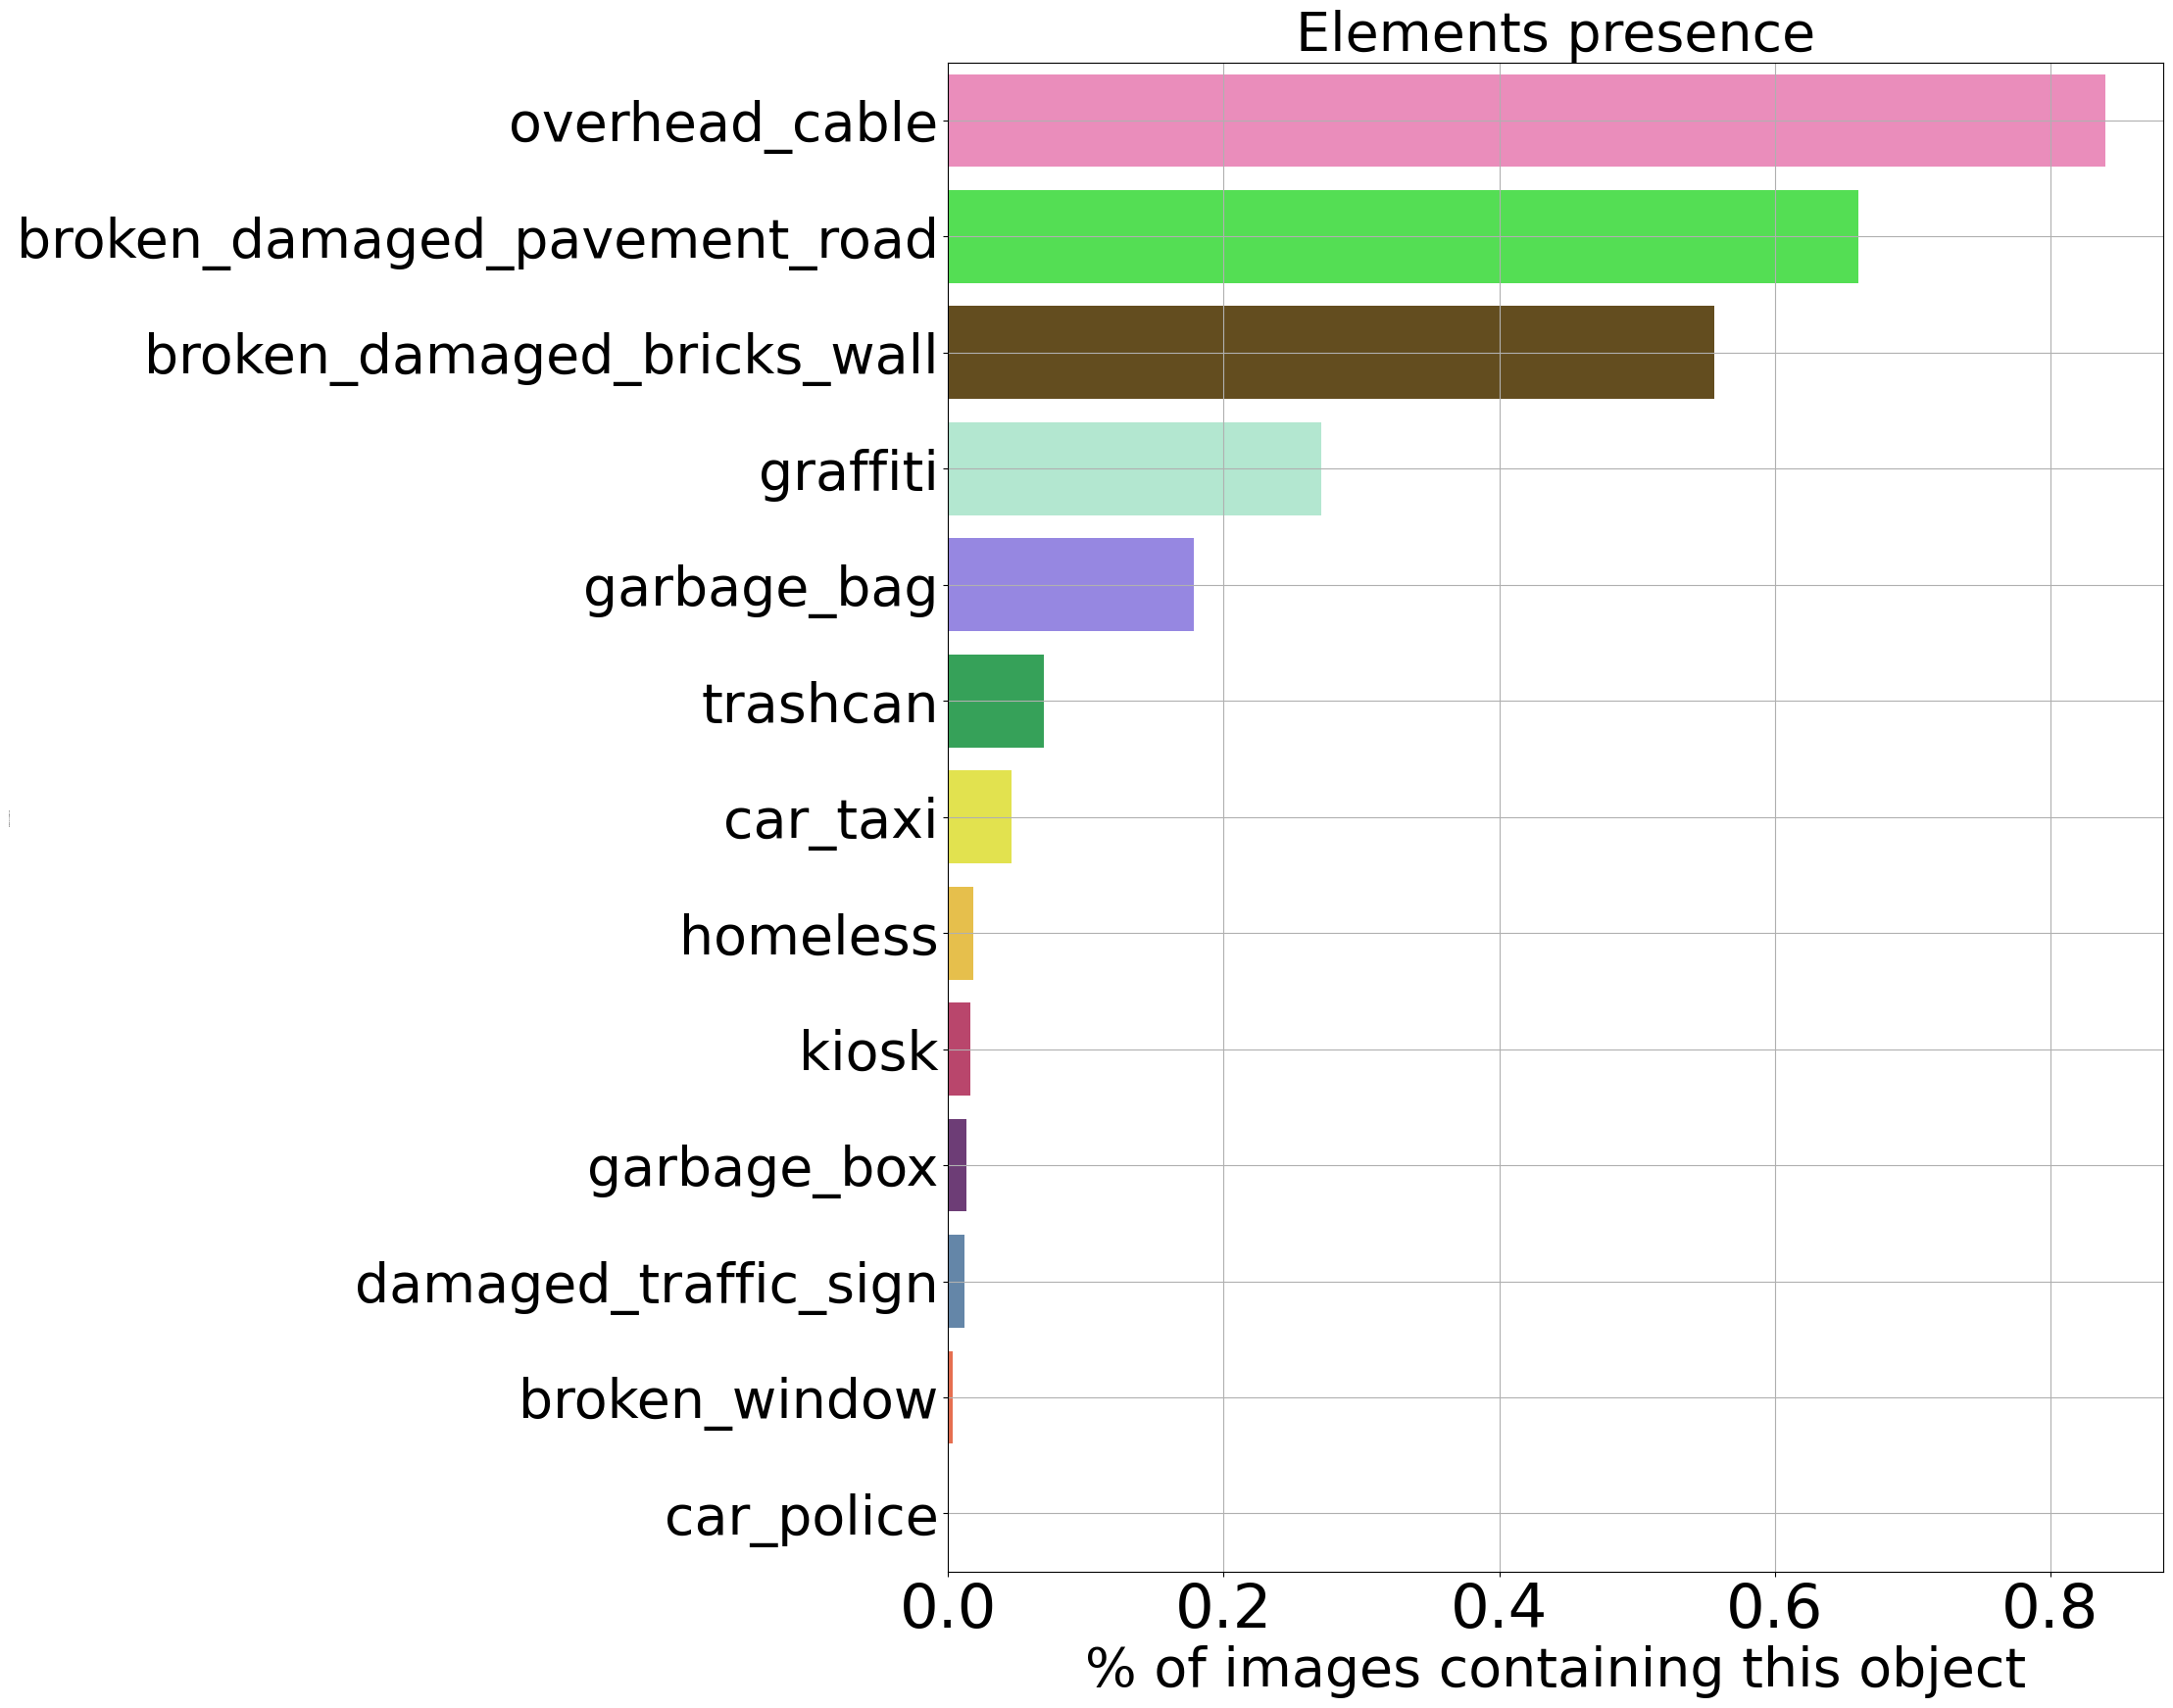

In [23]:
feature_presence = uss.features_presence(manual_segmentation_df[manual_segmentation_df[metric]<4].iloc[:, 17:])
uss.print_object_present(feature_presence, fig_size=(16,20))

### Boxplots

#### All samples

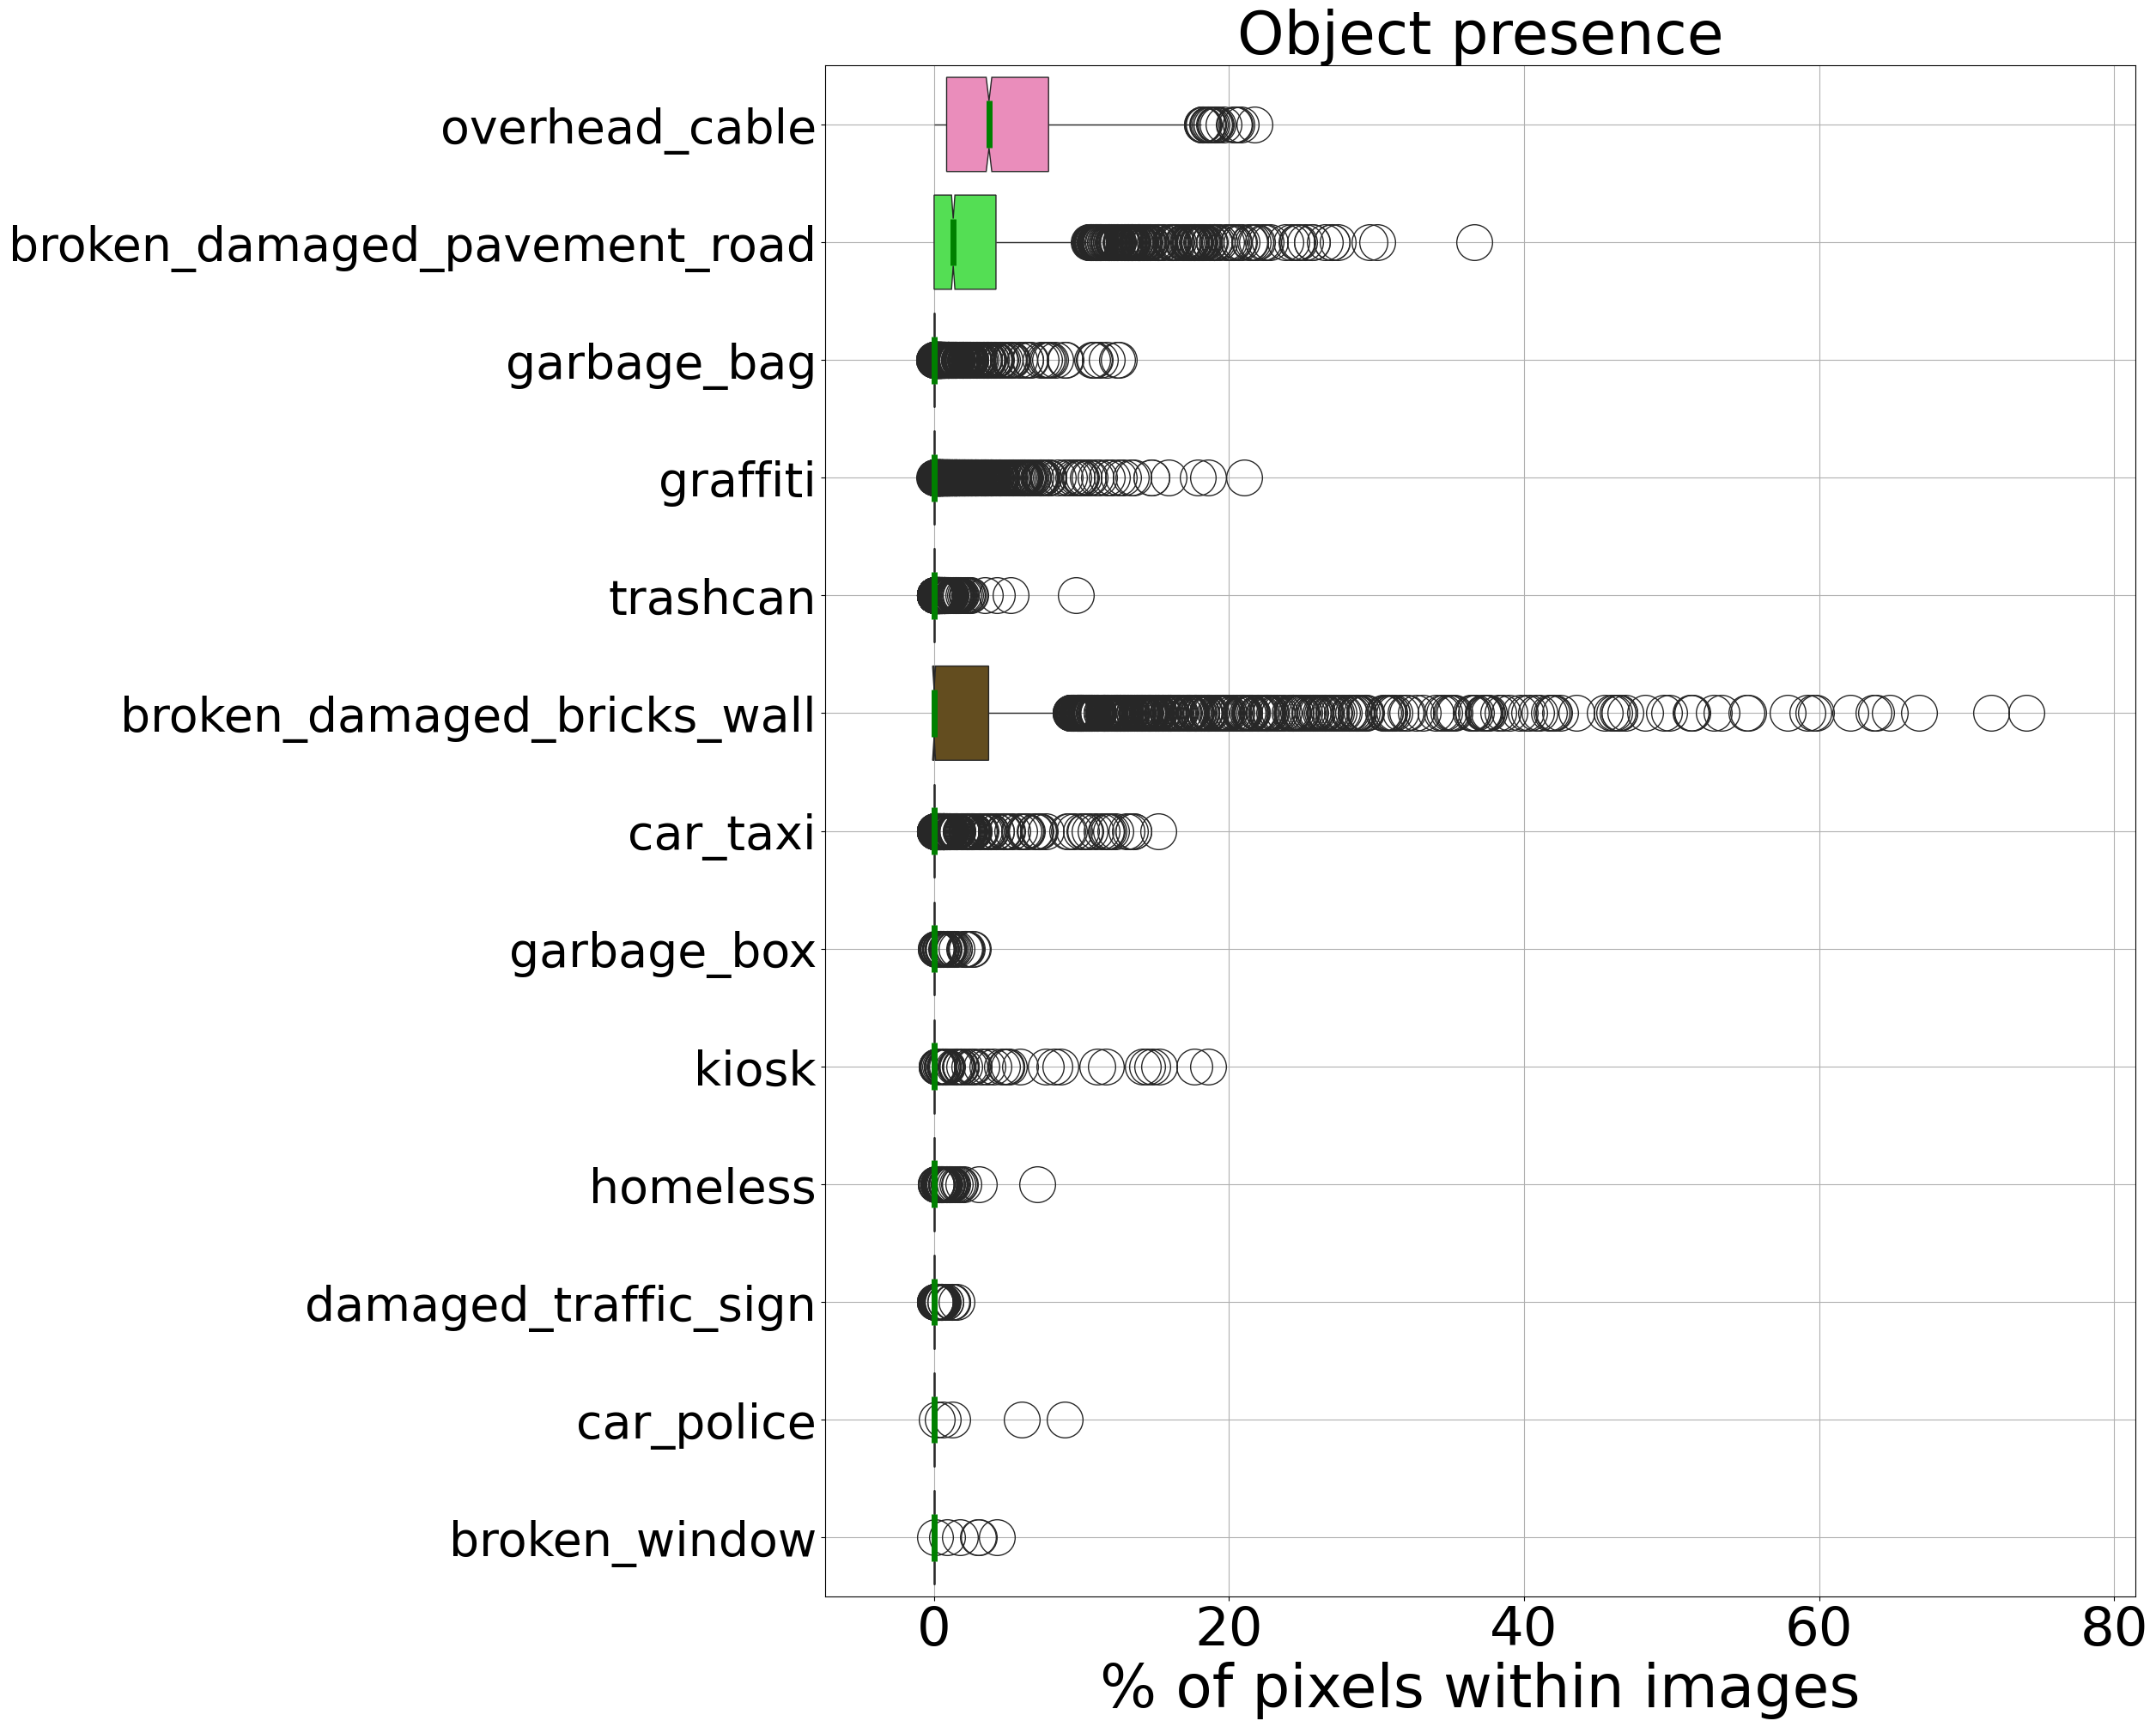

In [24]:
uss.print_object_boxplot(manual_segmentation_df.iloc[:, 17:]*100, fig_size=(25, 20))

#### Positive samples

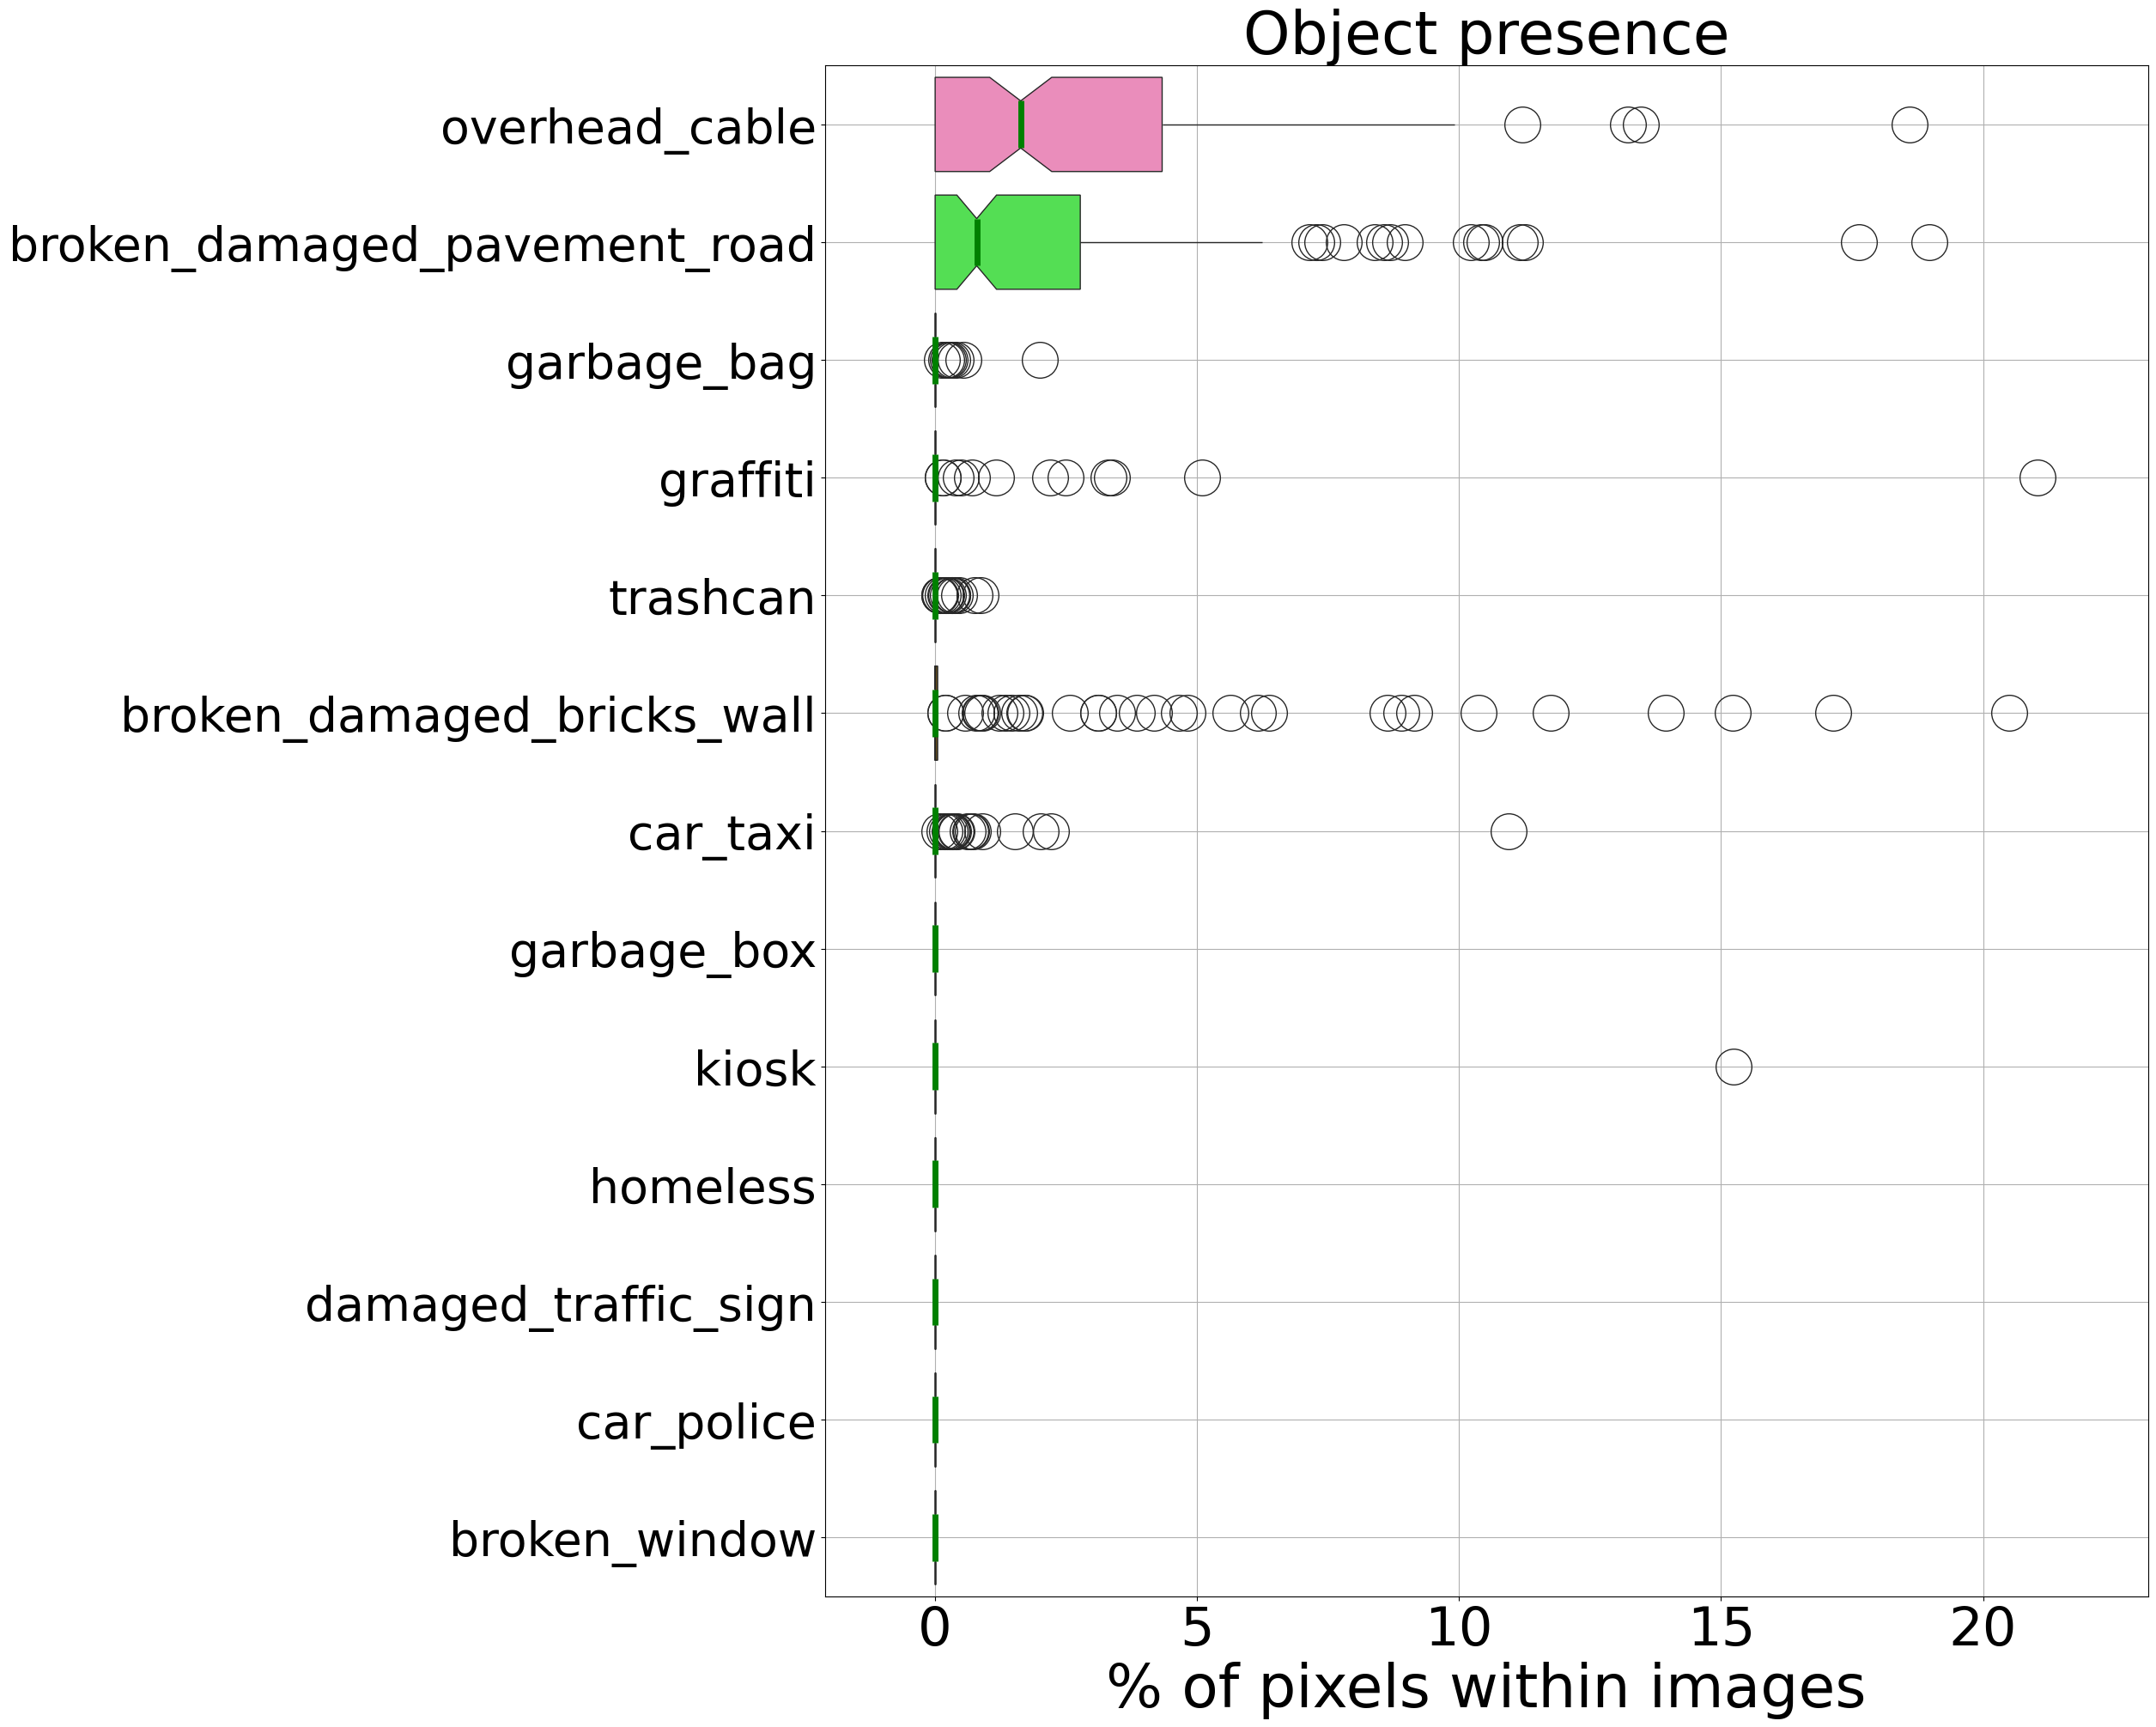

In [25]:
uss.print_object_boxplot(manual_segmentation_df[manual_segmentation_df[metric]>=6].iloc[:, 17:]*100, fig_size=(25, 20))

#### Negative samples

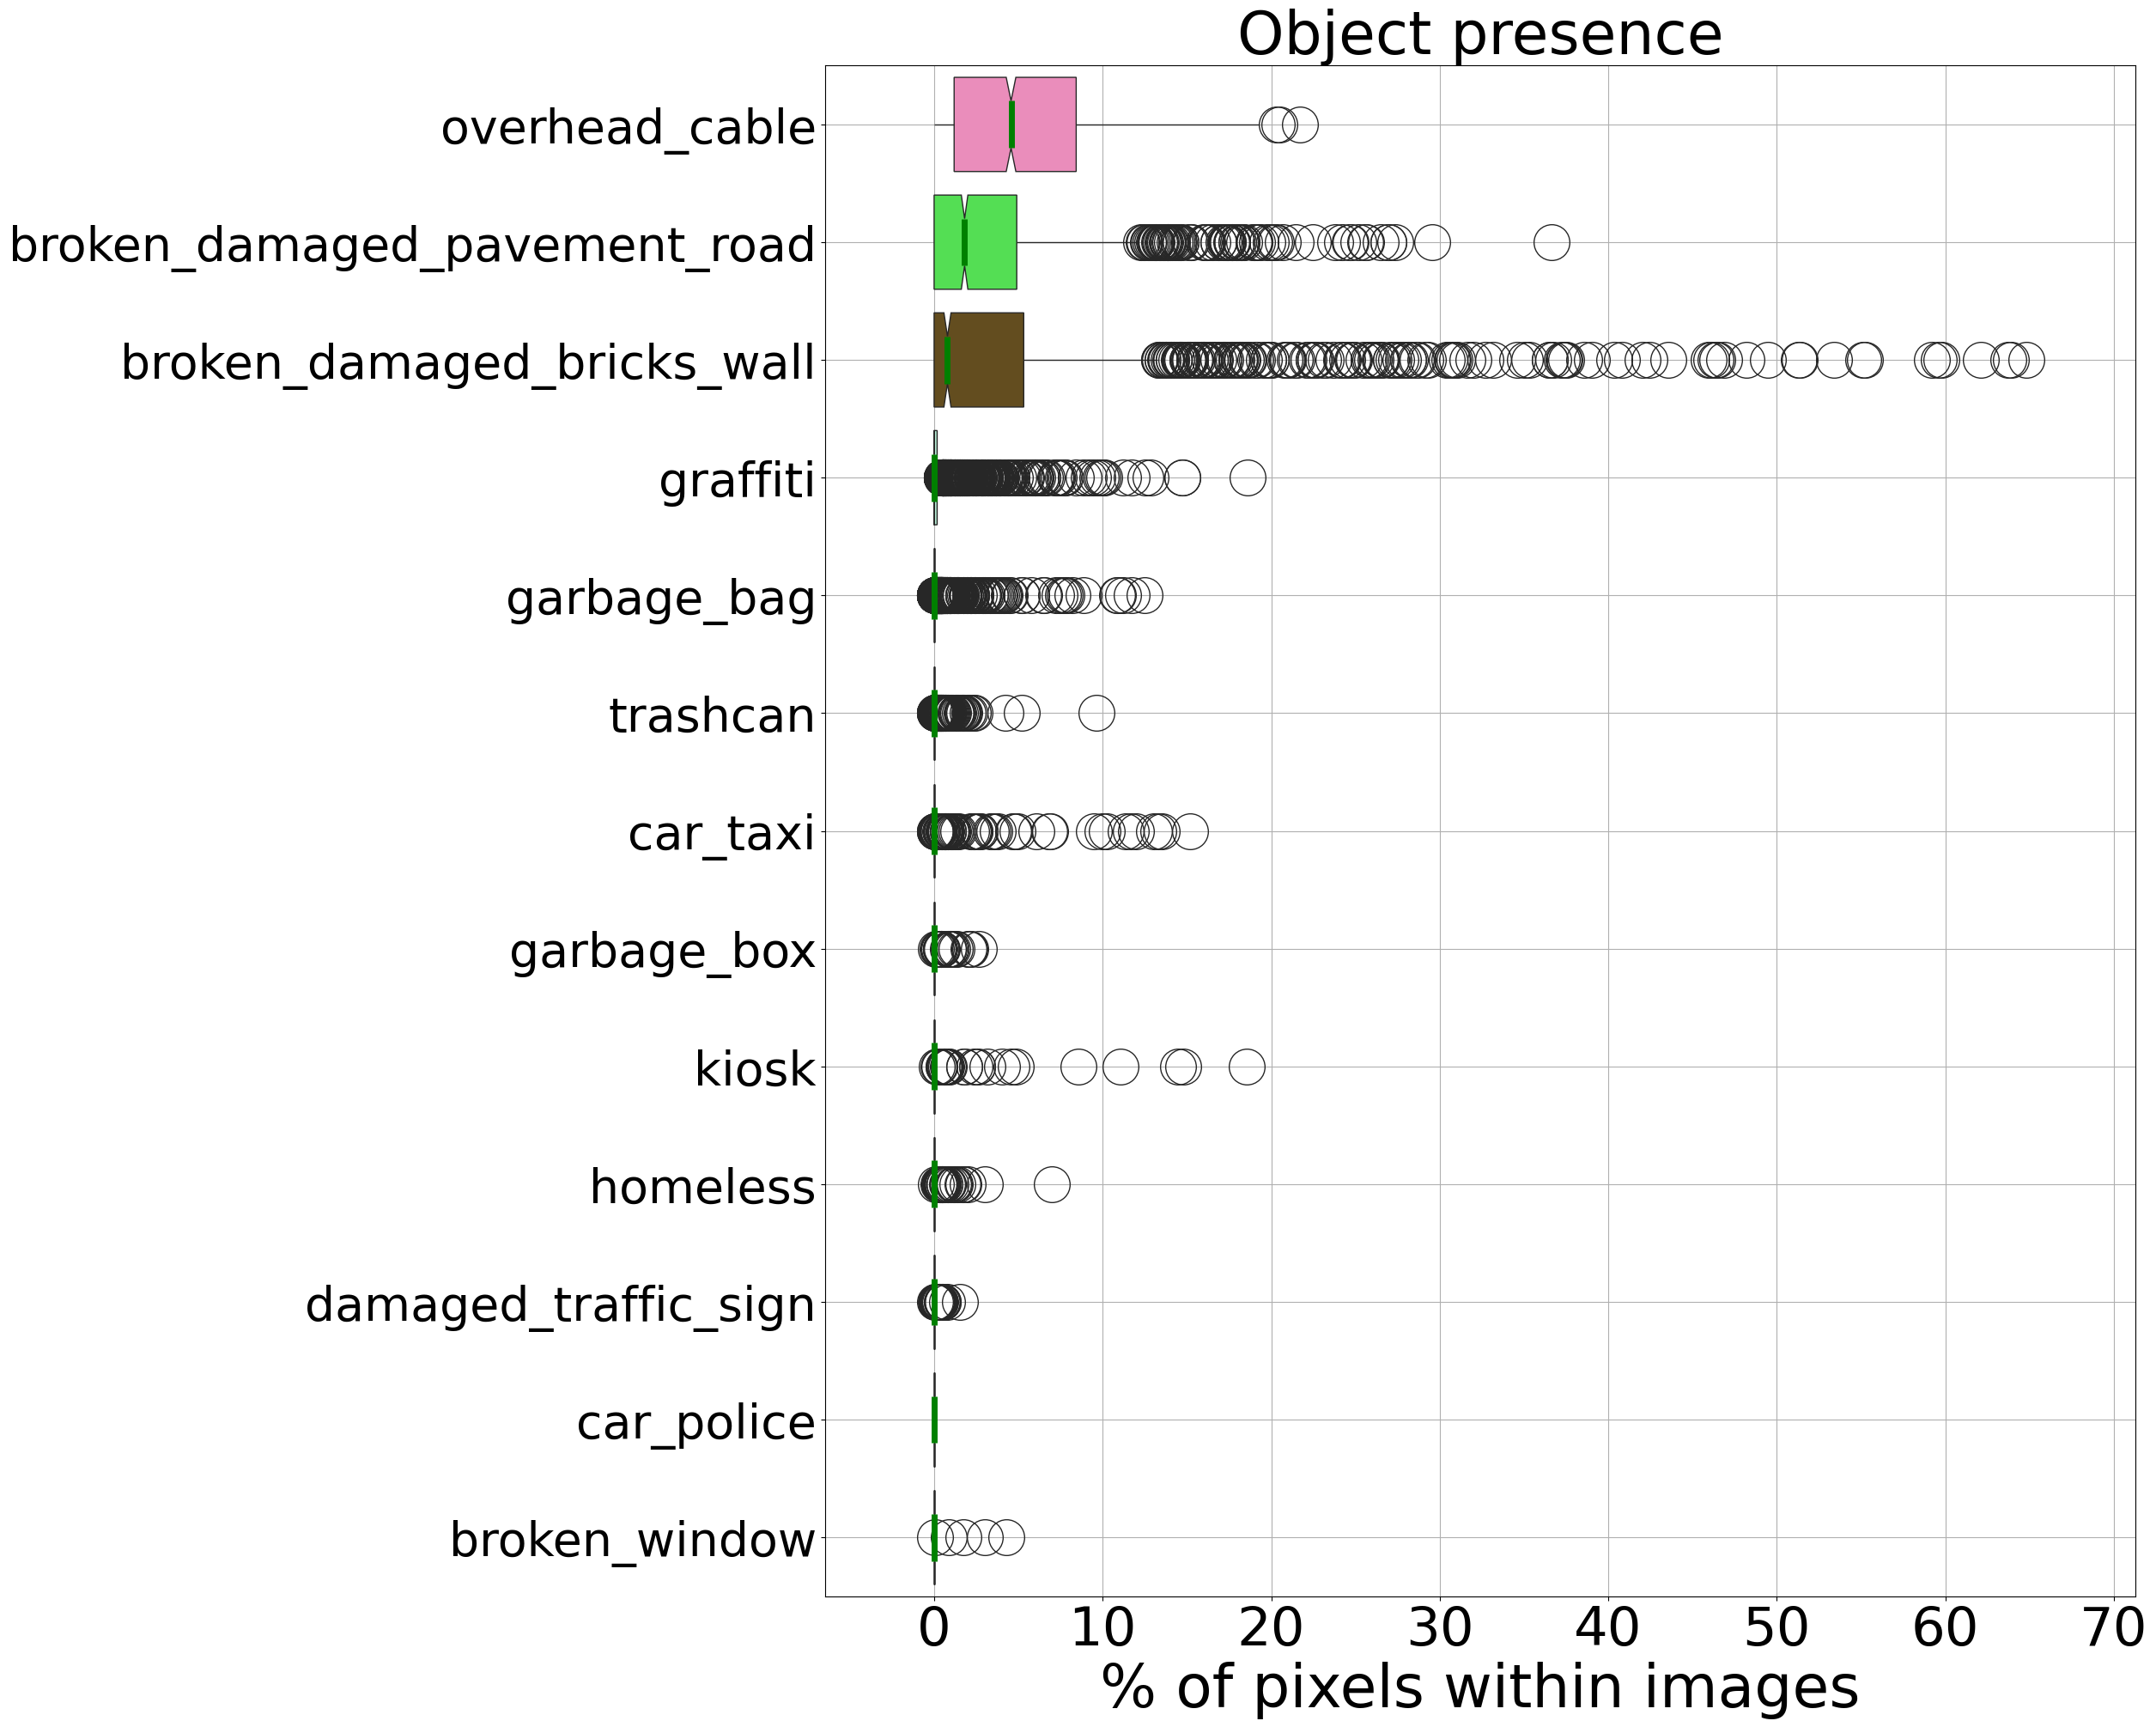

In [26]:
uss.print_object_boxplot(manual_segmentation_df[manual_segmentation_df[metric]<4].iloc[:, 17:]*100, fig_size=(25, 20))